# Transformer Recommendation Model Notebook

## Description
This notebook builds a transformer-based sequential recommendation model on the **MovieLens** dataset.

- **Task:** Next-item recommendation from user interaction history
- **Model:** Transformer encoder (SASRec-style sequence model)
- **Evaluation:** Hit Rate, Recall, Precision, NDCG @ K
- **Explainability:** Attention-based sequence inspection (optional)
- **Tuning:** Simple hyperparameter search over learning rate, dropout, hidden size, number of heads

## Workflow Management Guide
Use this notebook as a pipeline with clear stage boundaries:

1. **Data access**: verify MovieLens files and interaction schema.
2. **Sequence split**: build per-user time-ordered histories and leave-one-out split.
3. **Model definition**: keep architecture changes isolated in one class.
4. **Training utilities**: centralize data sampling, training loop, and ranking metrics.
5. **Baseline training**: create a stable reference before tuning.
6. **Evaluation**: compare ranking quality on validation/test with fixed candidate sampling.
7. **Explainability**: inspect attention patterns for qualitative checks.
8. **Tuning + retrain**: search a small config grid, then retrain the best setup.
9. **Artifact saving**: export model + mappings + config for reproducible inference.


In [12]:
# Optional installs if your environment is missing packages.
# %pip install -q pandas numpy scikit-learn torch matplotlib tqdm sentence-transformers


In [13]:
import json
import math
import os
import random
import re
import sys
from contextlib import nullcontext
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import TruncatedSVD
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm



In [14]:
# [Alex] Reproducibility setup (PyTorch version of random_state in scikit-learn)
# In scikit-learn, you often pass random_state=42 to split/model constructors.
# In PyTorch pipelines, randomness appears in more places (weight init, DataLoader shuffling,
# negative sampling, dropout masks), so we seed Python, NumPy, and Torch explicitly.
#
# Why this matters:
# - Makes experiments more comparable across reruns.
# - Reduces "noise" when tuning hyperparameters.
# - Helps debugging because behavior is less stochastic.
#
# Device strategy for Apple Silicon:
# - Prefer MPS on Mac M-series for much faster training than CPU.
# - Fall back to CUDA if available, otherwise CPU.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_float32_matmul_precision('high')

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# MPS is more stable in full precision for this notebook.
# Keep AMP for CUDA only.
USE_AMP = device.type == 'cuda'
AMP_DTYPE = torch.float16

# MPS-first knobs for stability/speed tradeoff during frequent testing.
DEFAULT_BATCH_SIZE = 128 if device.type == 'mps' else 256
DEFAULT_EVAL_NEGATIVES = 50 if device.type == 'mps' else 100
ALLOW_CPU_FALLBACK = False

# Fast-iteration mode: keep only a subset of users for quick local tests.
# Set to False for full-data training runs.
DEV_SUBSET_MODE = True
MAX_USERS_FOR_DEV = 10000


# DataLoader knobs tuned for local training speed.
# In notebooks on macOS/Python 3.12, multiprocessing workers can fail to pickle
# classes defined in notebook cells (spawn mode). Use single-process loading by default.
IN_NOTEBOOK = 'ipykernel' in sys.modules
if IN_NOTEBOOK:
    LOADER_WORKERS = 0
else:
    LOADER_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = device.type == 'cuda'

print('device:', device)
print('USE_AMP:', USE_AMP, '| AMP_DTYPE:', AMP_DTYPE)
print('IN_NOTEBOOK:', IN_NOTEBOOK)
print('LOADER_WORKERS:', LOADER_WORKERS)
print('DEFAULT_BATCH_SIZE:', DEFAULT_BATCH_SIZE, '| DEFAULT_EVAL_NEGATIVES:', DEFAULT_EVAL_NEGATIVES)
print('ALLOW_CPU_FALLBACK:', ALLOW_CPU_FALLBACK)
print('DEV_SUBSET_MODE:', DEV_SUBSET_MODE, '| MAX_USERS_FOR_DEV:', MAX_USERS_FOR_DEV)




device: mps
USE_AMP: False | AMP_DTYPE: torch.float16
IN_NOTEBOOK: True
LOADER_WORKERS: 0
DEFAULT_BATCH_SIZE: 128 | DEFAULT_EVAL_NEGATIVES: 50
ALLOW_CPU_FALLBACK: False
DEV_SUBSET_MODE: True | MAX_USERS_FOR_DEV: 10000


In [15]:
# Optional helper if you want to download MovieLens manually:
# 1) Download ml-latest-small.zip from https://grouplens.org/datasets/movielens/latest/
# 2) Extract it under one of the candidate paths used below.

# from kaggle.api.kaggle_api_extended import KaggleApi

# api = KaggleApi()
# api.authenticate()

# api.dataset_download_files(
#     "grouplens/movielens-latest-full",
#     path="./data",
#     unzip=True
# )


## 1) Load Data

**Purpose:** Read MovieLens interactions and prepare a clean interaction table.

Expected files:
- `ratings.csv` (required)
- `movies.csv` (optional metadata)

**Management notes:**
- Keep path detection logic in this section only.
- Validate schema before moving to sequence modeling steps.


In [16]:
# [Alex] Data location and schema validation
# Think of this block as a robust "data loader" utility:
# 1) try several common directories,
# 2) fail fast with a clear error if ratings.csv is missing,
# 3) validate required columns before downstream processing.
#
# This is equivalent to strong input validation in an sklearn pipeline before fit().

candidate_dirs = [
    Path('Transformer/Data/ml-latest-small'),
    Path('Transformer/Data'),
    Path('Data/ml-latest-small'),
    Path('Data'),
    Path('.'),
]

ratings_path = None
movies_path = None
for d in candidate_dirs:
    rp = d / 'ratings.csv'
    mp = d / 'movies.csv'
    if rp.exists():
        ratings_path = rp
        movies_path = mp if mp.exists() else None
        break

if ratings_path is None:
    raise FileNotFoundError(
        'ratings.csv not found. Place MovieLens data in Transformer/Data or current directory.'
    )

ratings = pd.read_csv(ratings_path)
movies = pd.read_csv(movies_path) if movies_path is not None else None

required_cols = {'userId', 'movieId', 'rating', 'timestamp'}
missing = required_cols - set(ratings.columns)
if missing:
    raise ValueError(f'Missing required columns in ratings.csv: {missing}')

print('ratings_path:', ratings_path)
print('ratings shape:', ratings.shape)
if movies is not None:
    print('movies shape:', movies.shape)



ratings_path: Data/ratings.csv
ratings shape: (27753444, 4)
movies shape: (58098, 3)


In [ ]:
# [Alex] Convert explicit ratings into implicit feedback + clean sparse tails
# Recommendation sequence models usually learn from interaction events (clicked/watched/liked)
# rather than predicting the exact rating value. So we threshold ratings >= 4.0 as "positive".
#
# We then iteratively remove:
# - users with too few interactions,
# - items with too few interactions.
# This is similar to removing classes/features with too little support in classical ML.
#
# ID remapping to contiguous integers is required for nn.Embedding:
# - embeddings are lookup tables indexed by integer ids,
# - index 0 is reserved for PAD token, so real item ids start at 1.

ratings = ratings.copy()
ratings = ratings.sort_values(['userId', 'timestamp'])

MIN_POS_RATING = 4.0
interactions = ratings[ratings['rating'] >= MIN_POS_RATING][['userId', 'movieId', 'timestamp']].copy()

MIN_USER_INTERACTIONS = 5
MIN_ITEM_INTERACTIONS = 5

for _ in range(3):
    user_counts = interactions['userId'].value_counts()
    interactions = interactions[interactions['userId'].isin(user_counts[user_counts >= MIN_USER_INTERACTIONS].index)]
    item_counts = interactions['movieId'].value_counts()
    interactions = interactions[interactions['movieId'].isin(item_counts[item_counts >= MIN_ITEM_INTERACTIONS].index)]

interactions = interactions.sort_values(['userId', 'timestamp']).reset_index(drop=True)

if DEV_SUBSET_MODE and interactions['userId'].nunique() > MAX_USERS_FOR_DEV:
    sampled_users = (
        pd.Series(interactions['userId'].unique())
        .sample(n=MAX_USERS_FOR_DEV, random_state=SEED, replace=False)
        .tolist()
    )
    interactions = interactions[interactions['userId'].isin(sampled_users)]
    interactions = interactions.sort_values(['userId', 'timestamp']).reset_index(drop=True)
    print(f'DEV_SUBSET_MODE enabled: keeping {MAX_USERS_FOR_DEV} users for fast testing.')

user_ids = interactions['userId'].unique().tolist()
item_ids = interactions['movieId'].unique().tolist()
user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {m: i + 1 for i, m in enumerate(item_ids)}  # reserve 0 for padding
idx2item = {i: m for m, i in item2idx.items()}

interactions['user_idx'] = interactions['userId'].map(user2idx)
interactions['item_idx'] = interactions['movieId'].map(item2idx)

num_users = len(user2idx)
num_items = len(item2idx)

print('interactions shape:', interactions.shape)
print('num_users:', num_users)
print('num_items:', num_items)
interactions.head()

# Build frozen movie side features aligned to item_idx:
# 1) title embedding -> reduced dense vector
# 2) normalized production year scalar
# 3) pooled genre embedding
# these code create addtional table for movie attribles, 81 columns, 64 from title text
# 1 from production year and 16 from the genre
TITLE_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
TITLE_REDUCED_DIM = 64
GENRE_EMB_DIM = 16

movie_meta = pd.DataFrame({'movieId': item_ids, 'item_idx': [item2idx[m] for m in item_ids]})
if movies is not None:
    use_cols = [c for c in ['movieId', 'title', 'genres', 'year'] if c in movies.columns]
    movie_meta = movie_meta.merge(movies[use_cols], on='movieId', how='left')
else:
    movie_meta['title'] = ''
    movie_meta['genres'] = ''

if 'title' not in movie_meta.columns:
    movie_meta['title'] = ''
if 'genres' not in movie_meta.columns:
    movie_meta['genres'] = ''
movie_meta['title'] = movie_meta['title'].fillna('').astype(str)
movie_meta['genres'] = movie_meta['genres'].fillna('').astype(str)

# Year extraction: prefer explicit year column, else parse from title.
if 'year' in movie_meta.columns:
    year_series = pd.to_numeric(movie_meta['year'], errors='coerce')
else:
    parsed_year = movie_meta['title'].str.extract(r'((?:19|20)\d{2})', expand=False)
    year_series = pd.to_numeric(parsed_year, errors='coerce')

valid_year = year_series.dropna()
year_mean = float(valid_year.mean()) if len(valid_year) else 2000.0
year_std = float(valid_year.std()) if len(valid_year) and valid_year.std() > 0 else 1.0
movie_meta['year_norm'] = ((year_series.fillna(year_mean) - year_mean) / year_std).astype(np.float32)

print('Encoding titles with sentence-transformers:', TITLE_MODEL_NAME)
title_encoder = SentenceTransformer(TITLE_MODEL_NAME)
title_embeddings = title_encoder.encode(
    movie_meta['title'].tolist(),
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

svd_dim = max(1, min(TITLE_REDUCED_DIM, title_embeddings.shape[0], title_embeddings.shape[1]))
title_svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
title_reduced = title_svd.fit_transform(title_embeddings).astype(np.float32)
if svd_dim < TITLE_REDUCED_DIM:
    pad = np.zeros((title_reduced.shape[0], TITLE_REDUCED_DIM - svd_dim), dtype=np.float32)
    title_reduced = np.hstack([title_reduced, pad])

# Genre pooled embeddings (fixed random vectors per genre, mean pooled per movie).
all_genres = set()
for g in movie_meta['genres'].tolist():
    if not g or g == '(no genres listed)':
        continue
    all_genres.update([x for x in g.split('|') if x])
genre_vocab = sorted(all_genres)

rng = np.random.default_rng(SEED)
genre_vecs = {
    g: rng.normal(0.0, 0.1, size=(GENRE_EMB_DIM,)).astype(np.float32)
    for g in genre_vocab
}

genre_features = np.zeros((len(movie_meta), GENRE_EMB_DIM), dtype=np.float32)
for i, g in enumerate(movie_meta['genres'].tolist()):
    parts = [x for x in g.split('|') if x and x != '(no genres listed)']
    if parts:
        genre_features[i] = np.mean([genre_vecs[p] for p in parts if p in genre_vecs], axis=0)

# Assemble item-side feature matrix with padding row at index 0.
item_title_features = np.zeros((num_items + 1, TITLE_REDUCED_DIM), dtype=np.float32)
item_year_features = np.zeros((num_items + 1, 1), dtype=np.float32)
item_genre_features = np.zeros((num_items + 1, GENRE_EMB_DIM), dtype=np.float32)

item_indices = movie_meta['item_idx'].to_numpy(dtype=np.int64)
item_title_features[item_indices] = title_reduced
item_year_features[item_indices, 0] = movie_meta['year_norm'].to_numpy(dtype=np.float32)
item_genre_features[item_indices] = genre_features

item_side_features = torch.tensor(
    np.concatenate([item_title_features, item_year_features, item_genre_features], axis=1),
    dtype=torch.float32,
)

print('item_side_features shape:', tuple(item_side_features.shape))
print('title dim:', TITLE_REDUCED_DIM, '| year dim: 1 | genre dim:', GENRE_EMB_DIM)




DEV_SUBSET_MODE enabled: keeping 10000 users for fast testing.
interactions shape: (594479, 5)
num_users: 10000
num_items: 14093
Encoding titles with sentence-transformers: sentence-transformers/all-MiniLM-L6-v2


Batches:   0%|          | 0/56 [00:00<?, ?it/s]

item_side_features shape: (14094, 81)
title dim: 64 | year dim: 1 | genre dim: 16


/Users/youxiaobin/anaconda3/envs/mlmain312/lib/python3.12/site-packages/sklearn/utils/extmath.py:337: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/youxiaobin/anaconda3/envs/mlmain312/lib/python3.12/site-packages/sklearn/utils/extmath.py:337: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/youxiaobin/anaconda3/envs/mlmain312/lib/python3.12/site-packages/sklearn/utils/extmath.py:337: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/youxiaobin/anaconda3/envs/mlmain312/lib/python3.12/site-packages/sklearn/utils/extmath.py:338: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/youxiaobin/anaconda3/envs/mlmain312/lib/python3.12/site-packages/sklearn/utils/extmath.py:338: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/youxiaobin/anaconda3/envs/mlmain312/lib/python3.12/site-packages/sklearn/utils/extmath.py:33

## 2) Train / Validation / Test Split

**Purpose:** Build per-user ordered sequences and create leave-one-out splits.

**Split policy:**
- Train history: all but last two interactions per user
- Validation target: second-to-last item
- Test target: last item

**Management notes:**
- This split reflects real-time recommendation (predicting future clicks/watchs).
- Do not tune on test targets.


In [18]:
# [Alex] Temporal split (train/val/test) for next-item prediction
# For each user sequence, we do a leave-last-two split:
# - train sequence: all but last 2 items
# - validation target: second last item
# - test target: last item
#
# This mimics real production timing (predict future from past), unlike random split.
# In sklearn terms, this is closer to time-aware validation than random train_test_split.

MAX_SEQ_LEN = 50

# user_histories example: {
#     user_id_1: [item_id_1, item_id_2, item_id_3, ...],
#     user_id_2: [item_id_7, item_id_2, item_id_9, ...],
#     user_id_3: [item_id_4, item_id_8, ...],
#     ...
# }
user_histories: Dict[int, List[int]] = {}
for uid, group in interactions.groupby('user_idx'):
    user_histories[uid] = group.sort_values('timestamp')['item_idx'].tolist()

# Keep users with enough sequence length for leave-one-out split.
user_histories = {u: seq for u, seq in user_histories.items() if len(seq) >= 3}
valid_users = sorted(user_histories.keys())

# the model data construction is taking the last 2 position of movie id for validation and testing,
# the preference of each user are learnt from interaction before position -2
train_sequences = {}
val_targets = {}
test_targets = {}
for u in valid_users:
    seq = user_histories[u]
    train_sequences[u] = seq[:-2]
    val_targets[u] = seq[-2]
    test_targets[u] = seq[-1]

print('users kept for modeling:', len(valid_users))



users kept for modeling: 10000


In [19]:
# [Alex] Build supervised training samples from each user history
# A sequence model still needs supervised examples. For each prefix we create one target:
# [i1] -> i2, [i1,i2] -> i3, ...
#
# Conceptually, this is similar to transforming one long time series into many
# (X, y) windows before model.fit(). max_len truncates context to bound memory/compute.

def build_train_examples(train_seqs: Dict[int, List[int]], max_len: int) -> List[Tuple[int, List[int], int]]:
    """
    Build (user, input_sequence, target_item) examples from each user's train history.
    For sequence [i1, i2, i3, i4], generate:
      [i1] -> i2, [i1, i2] -> i3, [i1, i2, i3] -> i4
    """
    examples = []
    for u, seq in train_seqs.items():
        if len(seq) < 2:
            continue
        for t in range(1, len(seq)):
            prefix = seq[max(0, t - max_len):t]
            target = seq[t]
            examples.append((u, prefix, target))
    return examples


train_examples = build_train_examples(train_sequences, MAX_SEQ_LEN)
print('train examples:', len(train_examples))



train examples: 564479


## 3) Define Transformer Model

**Purpose:** Define a sequence encoder that predicts the next item from user history.

**Architecture components:**
- Item embedding + positional embedding
- Transformer encoder stack
- Final hidden state projection to item vocabulary logits

**Management notes:**
- Keep model architecture changes inside this class.
- Preserve padding mask behavior when modifying sequence logic.


In [ ]:
# [Alex] Dataset + Transformer model definitions
# SeqRecDataset is the PyTorch equivalent of a custom data generator.

class SeqRecDataset(Dataset):
    def __init__(
        self,
        examples: List[Tuple[int, List[int], int]],
        max_len: int,
        num_items: int,
        num_negatives: int = 1,
    ):
        self.examples = examples
        self.max_len = max_len
        self.num_items = num_items
        self.num_negatives = num_negatives

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        user, seq, pos_item = self.examples[idx]
        seq = seq[-self.max_len:]
        pad_len = self.max_len - len(seq)
        input_ids = [0] * pad_len + seq

        neg_items = []
        while len(neg_items) < self.num_negatives:
            neg = random.randint(1, self.num_items)
            if neg != pos_item:
                neg_items.append(neg)

        return {
            'user': torch.tensor(user, dtype=torch.long),
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'pos_item': torch.tensor(pos_item, dtype=torch.long),
            'neg_items': torch.tensor(neg_items, dtype=torch.long),
        }


class TransformerRecModel(nn.Module):
    # Compared to the previous model:
    # 1. it passed the movie attribute as a separate dataset to the model class 
    # and do data transformation in the model class 
    # 2. it simply concatenate the item embedding and the additional 81 dimensions of 
    # feature to one big tensor 
    # 3. it adds another layer of linear transformation to convert it to 128 dimension 
    # 4. the rest are similar to the previous model
    def __init__(
        self,
        num_items: int,
        max_len: int,
        item_side_features: torch.Tensor,
        d_model: int = 128,
        n_heads: int = 4,
        n_layers: int = 2,
        dim_ff: int = 256,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.num_items = num_items
        self.max_len = max_len
        self.d_model = d_model

        self.item_emb = nn.Embedding(num_items + 1, d_model, padding_idx=0)
        self.register_buffer('item_side_features', item_side_features.clone().detach().float())
        self.side_dim = self.item_side_features.size(1)
        self.item_fusion = nn.Linear(d_model + self.side_dim, d_model, bias=False)

        self.pos_emb = nn.Embedding(max_len, d_model)
        self.emb_dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers, enable_nested_tensor=False
        )
        self.norm = nn.LayerNorm(d_model)

    def _item_repr(self, item_ids: torch.Tensor) -> torch.Tensor:
        base = self.item_emb(item_ids)
        side = self.item_side_features[item_ids]
        return self.item_fusion(torch.cat([base, side], dim=-1))

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        bsz, seqlen = input_ids.shape
        pos_ids = torch.arange(seqlen, device=input_ids.device).unsqueeze(0).expand(bsz, seqlen)

        x = self._item_repr(input_ids) + self.pos_emb(pos_ids)
        x = self.emb_dropout(x)

        pad_mask = input_ids.eq(0)
        h = self.encoder(x, src_key_padding_mask=pad_mask)
        h = self.norm(h)

        lengths = (~pad_mask).sum(dim=1).clamp(min=1)
        last_idx = lengths - 1
        seq_repr = h[torch.arange(bsz, device=h.device), last_idx]
        return seq_repr

    def score_items(self, seq_repr: torch.Tensor, item_ids: torch.Tensor) -> torch.Tensor:
        item_emb = self._item_repr(item_ids)
        return (seq_repr.unsqueeze(1) * item_emb).sum(dim=-1)

    def full_sort_scores(self, seq_repr: torch.Tensor) -> torch.Tensor:
        all_ids = torch.arange(self.num_items + 1, device=seq_repr.device)
        all_item_repr = self._item_repr(all_ids)
        return seq_repr @ all_item_repr.t()



## 4) Training Utilities

**Purpose:** Standardize training, validation, and ranking evaluation.

**Why this matters:**
- Keeps baseline/tuning/retrain runs comparable.
- Avoids metric drift from duplicated logic.

**Management notes:**
- Keep candidate sampling fixed for fair metric comparison.
- Seed all random generators before experiment loops.


In [ ]:
# [Alex] Training utilities
# TrainConfig centralizes hyperparameters so baseline/tuning/final runs stay comparable.
#
# BPR loss (Bayesian Personalized Ranking):
# - objective is not class probability calibration,
# - objective is ranking: score(pos_item) > score(neg_item).
#
# train_one_epoch follows the standard Torch loop:
# forward -> loss -> zero_grad -> backward -> gradient clipping -> optimizer.step
#
# evaluate_ranking computes top-k metrics with sampled negatives (common in recommender eval).
# This is a sampled approximation of full ranking, trading exactness for speed.

# @dataclass is a Python decorator that automatically generates special methods 

# #

# like __init__() and __repr__() for classes that are primarily used to store data. 
# In this case, TrainConfig is a simple container for training hyperparameters, and 
# using @dataclass makes it concise and readable without needing to write boilerplate 
# code for initialization.
@dataclass
class TrainConfig:
    max_len: int = 50
    batch_size: int = DEFAULT_BATCH_SIZE
    epochs: int = 20
    lr: float = 1e-3
    weight_decay: float = 1e-5
    d_model: int = 128
    n_heads: int = 4
    n_layers: int = 2
    dim_ff: int = 256
    dropout: float = 0.2
    num_negatives: int = 1
    eval_negatives: int = DEFAULT_EVAL_NEGATIVES


def bpr_loss(pos_scores: torch.Tensor, neg_scores: torch.Tensor) -> torch.Tensor:
    # Maximize margin between positive and negative scores.
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()


def train_one_epoch(model, loader, optimizer):
    # 1. for one epoch, train for n batches, with batch size 
    # 2. each batch we identify the postive score and negative score, they are tensors 
    # 3. we construct the los function using bpr loss 
    # 4. we use backward to calculate the gradient 
    # 5. then we use optimizer to update the weights 
    # 6. the training of one epoch returns the recorded average loss
    model.train()
    total_loss = 0.0
    steps = 0

    for batch in loader:
        # input movie ids
        input_ids = batch['input_ids'].to(device)
        pos_item = batch['pos_item'].to(device)
        neg_items = batch['neg_items'].to(device)  # [B, N]

        optimizer.zero_grad(set_to_none=True)

        with (torch.autocast(device_type=device.type, dtype=AMP_DTYPE) if USE_AMP else nullcontext()):
            seq_repr = model(input_ids)
            pos_scores = model.score_items(seq_repr, pos_item.unsqueeze(1)).squeeze(1)

            neg_scores = model.score_items(seq_repr, neg_items)
            neg_scores = neg_scores.mean(dim=1)

            loss = bpr_loss(pos_scores, neg_scores)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()
        steps += 1

    return total_loss / max(steps, 1)


@torch.no_grad()
def build_eval_input(train_seq: List[int], max_len: int) -> torch.Tensor:
    seq = train_seq[-max_len:]
    pad_len = max_len - len(seq)
    ids = [0] * pad_len + seq
    return torch.tensor(ids, dtype=torch.long)


@torch.no_grad()
def evaluate_ranking(
    model,
    train_sequences: Dict[int, List[int]],
    targets: Dict[int, int],
    user_histories: Dict[int, List[int]],
    num_items: int,
    max_len: int,
    k: int = 10,
    num_negatives: int = 100,
):
    # 1. train_sequence is the input, and the targets are the true label 
    # 2. use a created candidate set, with one true label and a few other negatives (n=num_negatives) for searching 
    # 3. the evaluation will check the hit rate, recall, precision and NDCG at K
    model.eval()

    hits, recalls, precisions, ndcgs = [], [], [], []

    for u in targets.keys():
        gt_item = targets[u]

        # Candidate set: 1 positive + sampled negatives not seen by user.
        seen = set(user_histories[u])
        candidates = [gt_item]
        while len(candidates) < num_negatives + 1:
            neg = random.randint(1, num_items)
            if neg not in seen and neg != gt_item:
                candidates.append(neg)

        input_ids = build_eval_input(train_sequences[u], max_len).unsqueeze(0).to(device)
        seq_repr = model(input_ids)

        cand_tensor = torch.tensor(candidates, dtype=torch.long, device=device).unsqueeze(0)
        scores = model.score_items(seq_repr, cand_tensor).squeeze(0).cpu().numpy()

        # Descending ranking.
        order = np.argsort(-scores)
        ranked_items = [candidates[i] for i in order]

        topk = ranked_items[:k]
        hit = 1.0 if gt_item in topk else 0.0
        hits.append(hit)
        recalls.append(hit)  # single ground-truth item
        precisions.append(hit / k)

        if gt_item in topk:
            rank = topk.index(gt_item) + 1
            ndcgs.append(1.0 / math.log2(rank + 1)) # if rank = 1, NDCG = 1, best result
        else:
            ndcgs.append(0.0)

    return {
        f'HitRate@{k}': float(np.mean(hits)),
        f'Recall@{k}': float(np.mean(recalls)),
        f'Precision@{k}': float(np.mean(precisions)),
        f'NDCG@{k}': float(np.mean(ndcgs)),
    }



## 5) Train Baseline Model

**Purpose:** Train a default transformer configuration to establish a reference result.

**Management notes:**
- Keep this as a stable baseline for future comparisons.
- Inspect train loss trend before relying on ranking metrics.


In [ ]:
# [Alex] Baseline training run
# This section is analogous to fitting a baseline sklearn model before hyperparameter search.
#
# Flow:
# - Build Dataset/DataLoader (batched minibatch training)
# - Instantiate Transformer model
# - Train with AdamW
# - Evaluate on validation target after each epoch
#
# We track both training loss and validation ranking quality because lower loss
# does not always mean better top-k recommendation performance.

baseline_cfg = TrainConfig()
train_batch_size = baseline_cfg.batch_size

def _build_train_loader(batch_size):
    train_dataset = SeqRecDataset(
        examples=train_examples,
        max_len=baseline_cfg.max_len,
        num_items=num_items,
        num_negatives=baseline_cfg.num_negatives,
    )
    return DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=LOADER_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=LOADER_WORKERS > 0,
    )

train_loader = _build_train_loader(train_batch_size)

def _init_baseline_model(train_device):
    model = TransformerRecModel(
        num_items=num_items,
        max_len=baseline_cfg.max_len,
        item_side_features=item_side_features,
        d_model=baseline_cfg.d_model,
        n_heads=baseline_cfg.n_heads,
        n_layers=baseline_cfg.n_layers,
        dim_ff=baseline_cfg.dim_ff,
        dropout=baseline_cfg.dropout,
    ).to(train_device)

    # Adam Optimizer, Adaptive Moment Estimation, update with momentum, generally faster for even range weights
    # SGD -> Adam (if overshooting) -> RMSP(Root Mean Squared Propagation)
    optim = torch.optim.AdamW(
        model.parameters(), lr=baseline_cfg.lr, weight_decay=baseline_cfg.weight_decay
    )
    return model, optim

def _run_baseline_training(model, optim):
    hist = {'train_loss': [], 'val_hr10': []}
    for epoch in range(1, baseline_cfg.epochs + 1):
        loss = train_one_epoch(model, train_loader, optim)
        val_metrics = evaluate_ranking(
            model,
            train_sequences=train_sequences,
            targets=val_targets,
            user_histories=user_histories,
            num_items=num_items,
            max_len=baseline_cfg.max_len,
            k=10,
            num_negatives=baseline_cfg.eval_negatives,
        )

        hist['train_loss'].append(loss)
        hist['val_hr10'].append(val_metrics['HitRate@10'])

        print(
            f"Epoch {epoch:02d} | loss={loss:.4f} | "
            f"val_HR@10={val_metrics['HitRate@10']:.4f} | val_NDCG@10={val_metrics['NDCG@10']:.4f}"
        )
    return hist

baseline_model, optimizer = _init_baseline_model(device)

try:
    history = _run_baseline_training(baseline_model, optimizer)
except (RuntimeError, NotImplementedError) as err:
    msg = str(err).lower()
    mps_failed = device.type == 'mps' and any(
        token in msg for token in ('mps', 'metal', 'command buffer', 'gpu', 'agx', 'nested_tensor', 'aten::_nested_tensor_from_mask_left_aligned')
    )
    if not mps_failed:
        raise

    if hasattr(torch, 'mps') and hasattr(torch.mps, 'empty_cache'):
        torch.mps.empty_cache()

    if train_batch_size > 32:
        train_batch_size = max(32, train_batch_size // 2)
        print(f'MPS backend failed; retrying on MPS with batch_size={train_batch_size}.')
        train_loader = _build_train_loader(train_batch_size)
        baseline_model, optimizer = _init_baseline_model(device)
        history = _run_baseline_training(baseline_model, optimizer)
    elif ALLOW_CPU_FALLBACK:
        print('MPS backend still failing; retrying on CPU because ALLOW_CPU_FALLBACK=True.')
        device = torch.device('cpu')
        USE_AMP = False
        PIN_MEMORY = False
        baseline_model, optimizer = _init_baseline_model(device)
        history = _run_baseline_training(baseline_model, optimizer)
    else:
        raise RuntimeError(
            'MPS failed and CPU fallback is disabled. Reduce model/batch or set ALLOW_CPU_FALLBACK=True.'
        ) from err









Epoch 01 | loss=0.3522 | val_HR@10=0.8872 | val_NDCG@10=0.6189
Epoch 02 | loss=0.1647 | val_HR@10=0.9072 | val_NDCG@10=0.6429
Epoch 03 | loss=0.1504 | val_HR@10=0.9192 | val_NDCG@10=0.6667
Epoch 04 | loss=0.1434 | val_HR@10=0.9245 | val_NDCG@10=0.6736
Epoch 05 | loss=0.1379 | val_HR@10=0.9252 | val_NDCG@10=0.6769
Epoch 06 | loss=0.1336 | val_HR@10=0.9306 | val_NDCG@10=0.6812
Epoch 07 | loss=0.1290 | val_HR@10=0.9324 | val_NDCG@10=0.6861
Epoch 08 | loss=0.1247 | val_HR@10=0.9341 | val_NDCG@10=0.6913
Epoch 09 | loss=0.1230 | val_HR@10=0.9371 | val_NDCG@10=0.6940
Epoch 10 | loss=0.1197 | val_HR@10=0.9351 | val_NDCG@10=0.6946
Epoch 11 | loss=0.1164 | val_HR@10=0.9353 | val_NDCG@10=0.6994
Epoch 12 | loss=0.1154 | val_HR@10=0.9407 | val_NDCG@10=0.7069
Epoch 13 | loss=0.1145 | val_HR@10=0.9386 | val_NDCG@10=0.7061
Epoch 14 | loss=0.1135 | val_HR@10=0.9418 | val_NDCG@10=0.7048
Epoch 15 | loss=0.1114 | val_HR@10=0.9410 | val_NDCG@10=0.7007
Epoch 16 | loss=0.1103 | val_HR@10=0.9414 | val_NDCG@10

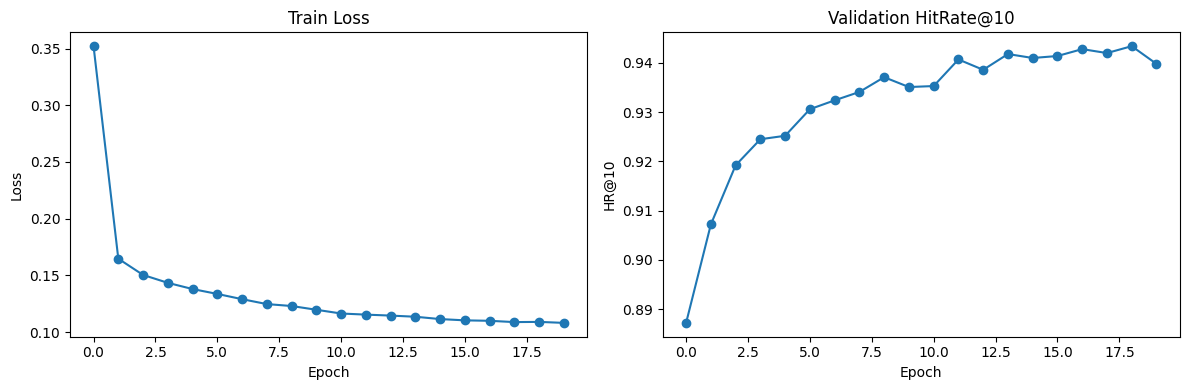

In [23]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], marker='o')
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(history['val_hr10'], marker='o')
axes[1].set_title('Validation HitRate@10')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('HR@10')

plt.tight_layout()
plt.show()


## 6) Test Evaluation

**Purpose:** Report ranking metrics for validation and final test targets.

**Management notes:**
- Use the same candidate sampling setup for all model comparisons.
- Treat test metrics as final reporting only.


In [24]:
# [Alex] Validation and test evaluation protocol
# Important detail for test-time fairness:
# - when predicting test target, we allow the model to "know" the validation interaction,
#   so prefix becomes train + val (train_plus_val).
#
# This mirrors chronological deployment: by the time you predict the last event,
# earlier events (including former validation step) are already observed.

baseline_val_metrics = evaluate_ranking(
    baseline_model,
    train_sequences=train_sequences,
    targets=val_targets,
    user_histories=user_histories,
    num_items=num_items,
    max_len=baseline_cfg.max_len,
    k=10,
    num_negatives=baseline_cfg.eval_negatives,
)

# For test evaluation, include validation target in known prefix.
train_plus_val = {
    u: train_sequences[u] + [val_targets[u]]
    for u in train_sequences
}

baseline_test_metrics = evaluate_ranking(
    baseline_model,
    train_sequences=train_plus_val,
    targets=test_targets,
    user_histories=user_histories,
    num_items=num_items,
    max_len=baseline_cfg.max_len,
    k=10,
    num_negatives=baseline_cfg.eval_negatives,
)

print('Baseline validation metrics:')
print(json.dumps(baseline_val_metrics, indent=2))
print('Baseline test metrics:')
print(json.dumps(baseline_test_metrics, indent=2))



Baseline validation metrics:
{
  "HitRate@10": 0.9413,
  "Recall@10": 0.9413,
  "Precision@10": 0.09413000000000002,
  "NDCG@10": 0.7074507195591002
}
Baseline test metrics:
{
  "HitRate@10": 0.9284,
  "Recall@10": 0.9284,
  "Precision@10": 0.09284,
  "NDCG@10": 0.6796543358870074
}


In [25]:
# Compare multiple cutoff values for the same trained baseline.
for k in [5, 10, 20]:
    m = evaluate_ranking(
        baseline_model,
        train_sequences=train_plus_val,
        targets=test_targets,
        user_histories=user_histories,
        num_items=num_items,
        max_len=baseline_cfg.max_len,
        k=k,
        num_negatives=baseline_cfg.eval_negatives,
    )
    print(f"k={k}: {m}")


k=5: {'HitRate@5': 0.8309, 'Recall@5': 0.8309, 'Precision@5': 0.16618, 'NDCG@5': 0.647042818738114}
k=10: {'HitRate@10': 0.9317, 'Recall@10': 0.9317, 'Precision@10': 0.09317, 'NDCG@10': 0.683891400042973}
k=20: {'HitRate@20': 0.9738, 'Recall@20': 0.9738, 'Precision@20': 0.04869000000000001, 'NDCG@20': 0.6928897291787633}


## 7) Explainability with Attention Inspection (Optional)

**Purpose:** Provide qualitative debugging by inspecting which sequence positions receive stronger attention.

**Notes:**
- This is a sanity-check tool, not a causal explanation.
- Run on a small number of users for quick iteration.


In [26]:
# [Alex] Lightweight explainability via top-N recommendation inspection
# This is not SHAP; instead we inspect concrete recommendation outputs for one user:
# - feed user's recent sequence,
# - score all items,
# - print top predictions.
#
# Useful for sanity checks (e.g., are recommendations plausible/diverse?).

@torch.no_grad()
def inspect_user_sequence(user_idx: int, model, train_sequences, idx2item, max_len=50, topn=10):
    model.eval()
    seq = train_sequences[user_idx][-max_len:]
    if not seq:
        print('Empty sequence for user', user_idx)
        return

    input_ids = build_eval_input(seq, max_len).unsqueeze(0).to(device)
    seq_repr = model(input_ids)
    scores = model.full_sort_scores(seq_repr).squeeze(0).cpu().numpy()

    # Exclude padding id = 0.
    top_items = np.argsort(-scores[1:])[:topn] + 1
    mapped = [idx2item[i] for i in top_items if i in idx2item]

    print(f'user_idx={user_idx}')
    print('recent sequence item_idx:', seq[-10:])
    print('top recommended item_idx:', top_items.tolist())
    print('top recommended movieId:', mapped)

sample_user = valid_users[0]
inspect_user_sequence(sample_user, baseline_model, train_sequences, idx2item, max_len=MAX_SEQ_LEN, topn=10)



user_idx=0
recent sequence item_idx: [183, 184, 185, 186, 187, 188, 189, 190, 191, 192]
top recommended item_idx: [31, 188, 43, 141, 420, 376, 255, 227, 130, 458]
top recommended movieId: [356, 919, 1247, 1225, 5060, 260, 858, 1097, 1207, 2716]


## 8) Hyperparameter Tuning (Simple Search)

**Purpose:** Run a compact config search and rank configurations by validation HitRate@10.

**Management notes:**
- Keep the search space small and controlled.
- Use fixed seeds to make run-to-run comparison consistent.


In [27]:
# [Alex] Simple hyperparameter search
# We run a small manual grid (few configurations) to keep runtime practical.
#
# Re-seeding each trial reduces variance from random initialization/sampling,
# making trial-to-trial comparison more trustworthy.
#
# Metric for ranking configs is validation HR@10 (and NDCG@10 as supporting signal).

search_space = [
    {'lr': 1e-3, 'dropout': 0.2, 'd_model': 128, 'n_heads': 4},
    {'lr': 5e-4, 'dropout': 0.2, 'd_model': 128, 'n_heads': 4},
    {'lr': 1e-3, 'dropout': 0.3, 'd_model': 128, 'n_heads': 4},
    {'lr': 1e-3, 'dropout': 0.2, 'd_model': 256, 'n_heads': 8},
]

results = []
TUNE_EPOCHS = 4

for i, cfg in enumerate(search_space, start=1):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    tune_cfg = TrainConfig(
        max_len=MAX_SEQ_LEN,
        batch_size=DEFAULT_BATCH_SIZE,
        epochs=TUNE_EPOCHS,
        lr=cfg['lr'],
        d_model=cfg['d_model'],
        n_heads=cfg['n_heads'],
        dropout=cfg['dropout'],
    )

    model = TransformerRecModel(
        num_items=num_items,
        max_len=tune_cfg.max_len,
        item_side_features=item_side_features,
        d_model=tune_cfg.d_model,
        n_heads=tune_cfg.n_heads,
        n_layers=tune_cfg.n_layers,
        dim_ff=tune_cfg.dim_ff,
        dropout=tune_cfg.dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=tune_cfg.lr, weight_decay=tune_cfg.weight_decay)

    ds = SeqRecDataset(train_examples, max_len=tune_cfg.max_len, num_items=num_items, num_negatives=tune_cfg.num_negatives)
    dl = DataLoader(
        ds,
        batch_size=tune_cfg.batch_size,
        shuffle=True,
        num_workers=LOADER_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=LOADER_WORKERS > 0,
    )

    for _ in range(tune_cfg.epochs):
        _ = train_one_epoch(model, dl, optimizer)

    val_m = evaluate_ranking(
        model,
        train_sequences=train_sequences,
        targets=val_targets,
        user_histories=user_histories,
        num_items=num_items,
        max_len=tune_cfg.max_len,
        k=10,
        num_negatives=tune_cfg.eval_negatives,
    )

    row = {
        'trial': i,
        **cfg,
        'val_HR@10': val_m['HitRate@10'],
        'val_NDCG@10': val_m['NDCG@10'],
    }
    results.append(row)
    print(row)

results_df = pd.DataFrame(results).sort_values('val_HR@10', ascending=False).reset_index(drop=True)
results_df






{'trial': 1, 'lr': 0.001, 'dropout': 0.2, 'd_model': 128, 'n_heads': 4, 'val_HR@10': 0.9224, 'val_NDCG@10': 0.6747490401954801}
{'trial': 2, 'lr': 0.0005, 'dropout': 0.2, 'd_model': 128, 'n_heads': 4, 'val_HR@10': 0.9203, 'val_NDCG@10': 0.6711760256918246}
{'trial': 3, 'lr': 0.001, 'dropout': 0.3, 'd_model': 128, 'n_heads': 4, 'val_HR@10': 0.9224, 'val_NDCG@10': 0.6702178556769482}
{'trial': 4, 'lr': 0.001, 'dropout': 0.2, 'd_model': 256, 'n_heads': 8, 'val_HR@10': 0.9153, 'val_NDCG@10': 0.6524682795340182}


,trial,lr,dropout,d_model,n_heads,val_HR@10,val_NDCG@10
0,1,0.0010,0.2,128,4,0.9224,0.674749
1,3,0.0010,0.3,128,4,0.9224,0.670218
2,2,0.0005,0.2,128,4,0.9203,0.671176
3,4,0.0010,0.2,256,8,0.9153,0.652468


In [28]:
best_cfg = results_df.iloc[0].to_dict()
print('Best config:')
print(best_cfg)


Best config:
{'trial': 1.0, 'lr': 0.001, 'dropout': 0.2, 'd_model': 128.0, 'n_heads': 4.0, 'val_HR@10': 0.9224, 'val_NDCG@10': 0.6747490401954801}


## 9) Retrain Best Model and Final Test

**Purpose:** Retrain with selected hyperparameters and report final test metrics.

**Management notes:**
- Retraining isolates final metrics from tuning artifacts.
- Keep preprocessing and split policy unchanged.


In [29]:
# [Alex] Retrain with best hyperparameters and report final test metrics
# Standard ML workflow:
# 1) choose best config on validation,
# 2) retrain model under that config,
# 3) evaluate once on test set.
#
# Keep test set untouched during tuning to avoid optimistic bias.

final_cfg = TrainConfig(
    max_len=MAX_SEQ_LEN,
    batch_size=DEFAULT_BATCH_SIZE,
    epochs=20,
    lr=float(best_cfg['lr']),
    d_model=int(best_cfg['d_model']),
    n_heads=int(best_cfg['n_heads']),
    dropout=float(best_cfg['dropout']),
)

final_model = TransformerRecModel(
    num_items=num_items,
    max_len=final_cfg.max_len,
    item_side_features=item_side_features,
    d_model=final_cfg.d_model,
    n_heads=final_cfg.n_heads,
    n_layers=final_cfg.n_layers,
    dim_ff=final_cfg.dim_ff,
    dropout=final_cfg.dropout,
).to(device)

final_optimizer = torch.optim.AdamW(final_model.parameters(), lr=final_cfg.lr, weight_decay=final_cfg.weight_decay)
final_ds = SeqRecDataset(train_examples, max_len=final_cfg.max_len, num_items=num_items, num_negatives=final_cfg.num_negatives)
final_dl = DataLoader(
    final_ds,
    batch_size=final_cfg.batch_size,
    shuffle=True,
    num_workers=LOADER_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=LOADER_WORKERS > 0,
)

for epoch in range(1, final_cfg.epochs + 1):
    l = train_one_epoch(final_model, final_dl, final_optimizer)
    print(f'Final epoch {epoch:02d} loss={l:.4f}')

final_test_metrics = evaluate_ranking(
    final_model,
    train_sequences=train_plus_val,
    targets=test_targets,
    user_histories=user_histories,
    num_items=num_items,
    max_len=final_cfg.max_len,
    k=10,
    num_negatives=final_cfg.eval_negatives,
)

print('Final test metrics:')
print(json.dumps(final_test_metrics, indent=2))







Final epoch 01 loss=0.3528
Final epoch 02 loss=0.1649
Final epoch 03 loss=0.1510
Final epoch 04 loss=0.1429
Final epoch 05 loss=0.1374
Final epoch 06 loss=0.1332
Final epoch 07 loss=0.1288
Final epoch 08 loss=0.1242
Final epoch 09 loss=0.1223
Final epoch 10 loss=0.1199
Final epoch 11 loss=0.1176
Final epoch 12 loss=0.1166
Final epoch 13 loss=0.1141
Final epoch 14 loss=0.1129
Final epoch 15 loss=0.1110
Final epoch 16 loss=0.1111
Final epoch 17 loss=0.1095
Final epoch 18 loss=0.1088
Final epoch 19 loss=0.1092
Final epoch 20 loss=0.1100
Final test metrics:
{
  "HitRate@10": 0.9317,
  "Recall@10": 0.9317,
  "Precision@10": 0.09317000000000002,
  "NDCG@10": 0.687501112891762
}


## 10) Save Model Artifacts

**Purpose:** Save trained model and metadata needed for inference/reproducibility.

**Artifacts saved:**
- Model weights (`.pt`)
- Id mappings (`.json`)
- Final config + metrics (`.json`)

**Management notes:**
- Keep artifact versioning consistent when re-running experiments.


In [30]:
# [Alex] Persist artifacts for later inference/reproducibility
# We save three artifacts:
# - model checkpoint (weights + architecture hyperparameters)
# - id mappings (raw ids <-> embedding indices)
# - final report (config + metrics)
#
# This is similar to saving sklearn model + preprocessing metadata so predictions
# can be reproduced outside the notebook.

artifact_dir = Path('Transformer/artifacts')
artifact_dir.mkdir(parents=True, exist_ok=True)

model_path = artifact_dir / 'transformer_recommender.pt'
meta_path = artifact_dir / 'id_mappings.json'
report_path = artifact_dir / 'final_report.json'

torch.save(
    {
        'model_state_dict': final_model.state_dict(),
        'num_items': num_items,
        'max_len': final_cfg.max_len,
        'd_model': final_cfg.d_model,
        'n_heads': final_cfg.n_heads,
        'n_layers': final_cfg.n_layers,
        'dim_ff': final_cfg.dim_ff,
        'dropout': final_cfg.dropout,
        'side_feature_dim': int(item_side_features.shape[1]),
        'title_feature_dim': TITLE_REDUCED_DIM,
        'genre_feature_dim': GENRE_EMB_DIM,
    },
    model_path,
)

with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(
        {
            'user2idx': {str(k): int(v) for k, v in user2idx.items()},
            'item2idx': {str(k): int(v) for k, v in item2idx.items()},
            'idx2item': {str(k): int(v) for k, v in idx2item.items()},
        },
        f,
        indent=2,
    )

with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(
        {
            'final_config': final_cfg.__dict__,
            'final_test_metrics': final_test_metrics,
            'num_users': len(valid_users),
            'num_items': num_items,
            'seed': SEED,
        },
        f,
        indent=2,
    )

print('Saved artifacts:')
print('-', model_path)
print('-', meta_path)
print('-', report_path)




Saved artifacts:
- Transformer/artifacts/transformer_recommender.pt
- Transformer/artifacts/id_mappings.json
- Transformer/artifacts/final_report.json
